<a href="https://colab.research.google.com/github/Arsenii-S7/Stats_Learning/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Практика: Описательная статистика и Влияние выбросов (Задача 1)

## 📝 Условие задачи: "Гений в классе"

Вы анализируете результаты теста в малой группе студентов. Ваша цель — понять, насколько "типичны" баллы большинства и как один экстремальный результат влияет на общую статистику.

**Данные (баллы):** `15, 18, 20, 22, 19, 21, 45`

### 🎯 Задания:
1.  **Центральная тенденция**: Рассчитать **Среднее арифметическое** ($\bar{x}$) и **Медиану**. Сравнить их.
2.  **Метрики разброса**: Найти **Стандартное отклонение** ($\sigma$) и **Межквартильный размах** (IQR).
3.  **Детекция аномалий**: Перевести баллы в **Z-значения**. Найти студента, чей балл является выбросом (Z > 2).
4.  **Вывод**: Оценить, как "супермен" (балл 45) повлиял на среднее значение группы.

---

## 🛠 Математическая справка для кода:
*   `np.mean()` — среднее арифметическое (чувствительно к выбросам).
*   `np.median()` — медиана (устойчива к выбросам).
*   `stats.zscore()` — расчет отклонения каждой точки от среднего в единицах стандартного отклонения.
*   `stats.iqr()` — ширина "коробки" (центральные 50% данных).


In [ ]:
import numpy as np
from scipy import stats

# 1. Создаем массив данных
gr = np.array([15, 18, 20, 22, 19, 21, 45])

mean_val = np.mean(gr)
std_val = np.std(gr)
# 2. Считаем базовые метрики
print(f"Средний балл: {mean_val:.2f}")
print(f"Стандартное отклонение: {std_val:.2f}")

# 3. Рассчитываем Z-score
z_score = stats.zscore(gr)

print("\nВсе Z-значения:")
for s, z in zip(gr, z_score):
    print(f"Балл {s}: Z = {z:.2f}")

# 4. Считаем Межквартильный размах
iqr_val = stats.iqr(gr)
print(f"\nIQR (размах центральных 50%): {iqr_val:.2f}")

# 5. Проверка на выброс
last_z = z_score[-1]
if abs(last_z) > 2:
    print(f"\n⚠️ Внимание! Балл {gr[-1]} является статистическим выбросом (Z > 2)")
else:
    print(f"\n✅ Балл {gr[-1]} находится в пределах нормы.")


# 📊 Практика: Z-статистика и нормальное распределение

## 📝 Условие задачи: "Где я в общем рейтинге?"

Представьте, что вы прошли международный тест на знание статистики. Организаторы предоставили следующие данные по стране:
*   **Средний балл ($\mu$):** 100
*   **Стандартное отклонение ($\sigma$):** 15
*   **Ваш балл ($x$):** 130

### 🎯 Задания:
1.  **Стандартизация**: Рассчитать ваш **Z-score** вручную и проверить его с помощью Python. (На сколько сигм вы выше среднего?).
2.  **Процентиль**: С помощью функции `stats.norm.cdf()` определить, какой процент участников набрал балл **ниже**, чем у вас.
3.  **Критическое значение**: Используя `stats.norm.ppf()`, узнать, какой балл нужно было набрать, чтобы войти в **топ-5%** самых успешных участников.

---

## 🛠 Инструментарий Scipy:
1. `z = (x - mean) / std` — формула Z-преобразования.
2. `stats.norm.cdf(z)` — функция распределения (выдает площадь под кривой слева от Z).
3. `stats.norm.ppf(0.95)` — квантиль (выдает значение Z, отсекающее нужный процент данных).


In [ ]:
from scipy import stats
mean_val = 100
sd_val = 15
val = 130
z =  (val - mean_val)/ sd_val
print(f'1. Z-score: {z:.2f}')

# 2. Находим площадь под кривой (процент людей "позади")
# cdf — Cumulative Distribution Function
percent_below = stats.norm.cdf(z) * 100
# Сколько людей набрали БОЛЬШЕ (правый хвост)
percent_above = stats.norm.sf(z) * 100
print(f"2.1 Вы набрали больше баллов, чем {percent_below:.2f}% участников.")
print(f"2.2 Впереди вас: {percent_above:.2f}% участников.")

# 3. Находим порог для входа в ТОП-5%
# Нам нужен 95-й процентиль (0.95), так как топ-5% — это те, кто выше 95%
z_top_5 = stats.norm.ppf(0.95)
score_top_5 = val + z_top_5 * sd_val

print(f"3. Для попадания в ТОП-5% нужно набрать: {score_top_5:.2f} балла")

# 4. Сравнение
if val >= score_top_5:
    print("\n🏆 Поздравляем! Вы входите в ТОП-5%!")
else:
    print("\n📈 Вы показали отличный результат, но для ТОП-5% не хватило совсем чуть-чуть.")

1. Z-score: 2.00
2.1 Вы набрали больше баллов, чем 97.72% участников.
2.2 Впереди вас: 2.28% участников.
3. Для попадания в ТОП-5% нужно набрать: 154.67 балла

📈 Вы показали отличный результат, но для ТОП-5% не хватило совсем чуть-чуть.


# 📊 2.1 Тема: T-распределение (двухвыборочный t-тест)

## 🧪 Контекст
Биолог проверяет, ускоряет ли новый стимулятор `BioGrow` рост пшеницы.
Он измеряет высоту ростков (см) через 10 дней после посадки.

### 🌱 Данные
**Группа A (контроль, без обработки):**
`[23.1, 22.9, 23.1, 22.8, 23.1, 22.9, 23.2, 22.9, 23.2, 23.1, 22.9, 23.1]`

**Группа B (стимулятор):**
`[23.5, 23.7, 23.8, 23.9, 23.7, 23.8, 23.9, 23.8, 23.7, 23.9, 23.8, 23.7]`

## 🎯 Задание
1. Визуализируй распределения обеих групп (например, боксплот или точечный график).
2. Сформулируй нулевую и альтернативную гипотезы.
3. Проведи **двухвыборочный t-тест** (предполагая равные дисперсии или используя тест Уэлча – как посчитаешь нужным).
4. Выведи t-статистику и p-value.
5. Сделай вывод (α = 0.05).

## 🛠 Инструменты
- `scipy.stats.ttest_ind()`
- `matplotlib.pyplot` / `seaborn` (по желанию)

## ❓ Ожидаемый результат
Понимание, значимо ли различаются средние двух групп.

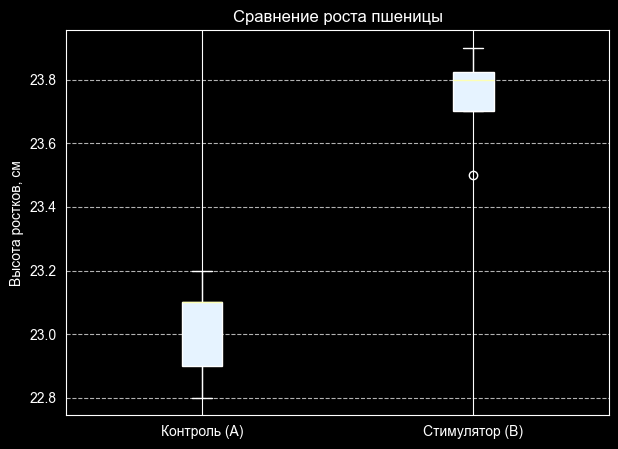

t-статистика: -14.42
p-value: 1.63e-12
Вывод: Отклоняем H0. Различия статистически значимы (p < 0.05).


In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

group_A = np.array([23.1, 22.9, 23.1, 22.8, 23.1, 22.9, 23.2, 22.9, 23.2, 23.1, 22.9, 23.1])
group_B = np.array([23.5, 23.7, 23.8, 23.9, 23.7, 23.8, 23.9, 23.8, 23.7, 23.9, 23.8, 23.7])

# 1. Визуализация
plt.figure(figsize=(7, 5))
plt.boxplot([group_A, group_B], tick_labels=['Контроль (A)', 'Стимулятор (B)'],
            patch_artist=True, boxprops=dict(facecolor='#e6f3ff'))
plt.ylabel('Высота ростков, см')
plt.title('Сравнение роста пшеницы')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. T-тест (используем тест Уэлча, так как он более универсален)
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=False)

# 3. Вывод результатов
print(f't-статистика: {t_stat:.2f}')
print(f'p-value: {p_value:.2e}') # Используем научную нотацию, так как p очень мало

# 4. Анализ
alpha = 0.05
if p_value < alpha:
    print(f"Вывод: Отклоняем H0. Различия статистически значимы (p < {alpha}).")
else:
    print(f"Вывод: Не удалось отклонить H0. Значимых различий не обнаружено.")

# 🧪 Тема 2.2: Сравнение двух средних (t-критерий Стьюдента) для независимых выборок

## 📌 Контекст
Исследователь хочет выяснить, различается ли средний прирост массы тела у мышей на двух разных диетах.

- **Диета X** (низкоуглеводная)
- **Диета Y** (сбалансированная)

Через 4 недели получены следующие значения прироста (в граммах):

## 📊 Данные

**Диета X (n = 10):**
`[5.2, 4.8, 5.5, 5.0, 4.9, 5.3, 5.1, 5.4, 5.2, 5.0]`

**Диета Y (n = 10):**
`[6.1, 5.9, 6.2, 5.8, 6.0, 6.3, 6.1, 6.0, 5.9, 6.2]`

## 🎯 Задание

1. Визуализируй обе выборки (боксплот или точечная диаграмма с jitter).
2. Сформулируй **нулевую** и **альтернативную** гипотезы.
3. Проведи **двухвыборочный t-тест Стьюдента**, предполагая равные дисперсии.
4. Выведи t-статистику, степени свободы и p‑value.
5. Сделай вывод при уровне значимости α = 0.05.

## 🛠 Инструменты
- `scipy.stats.ttest_ind(a, b, equal_var=True)`
- `matplotlib.pyplot` (boxplot / scatter)

## ✅ Ожидаемый результат
Понимание того, как правильно сравнивать средние двух независимых групп и интерпретировать результаты t-критерия.

Shapiro-Wilk: X: stat=0.9780, p=0.9535
Shapiro-Wilk: Y: stat=0.9657, p=0.8486


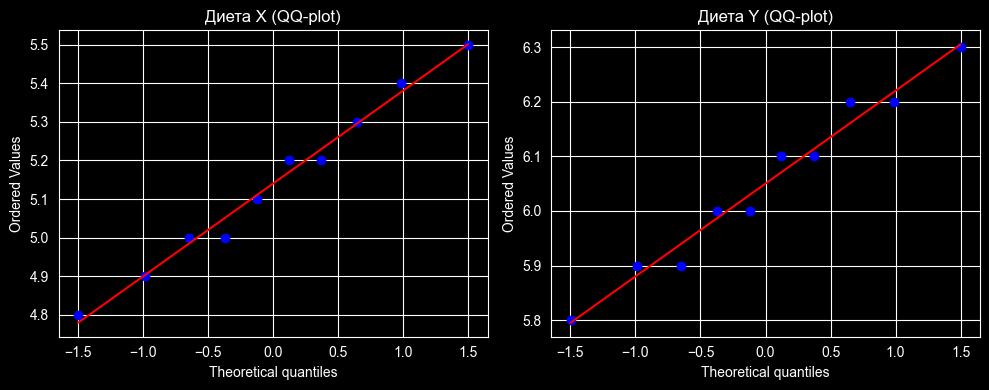

Данные нормальны → используем t-тест
t-тест: t=-10.5548, p=0.0000


In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

group_X = np.array([5.2, 4.8, 5.5, 5.0, 4.9, 5.3, 5.1, 5.4, 5.2, 5.0])
group_Y = np.array([6.1, 5.9, 6.2, 5.8, 6.0, 6.3, 6.1, 6.0, 5.9, 6.2])

# 1. Проверка нормальности (тест Шапиро-Уилка)
shapiro_X = stats.shapiro(group_X)
shapiro_Y = stats.shapiro(group_Y)
print(f"Shapiro-Wilk: X: stat={shapiro_X[0]:.4f}, p={shapiro_X[1]:.4f}")
print(f"Shapiro-Wilk: Y: stat={shapiro_Y[0]:.4f}, p={shapiro_Y[1]:.4f}")

# 2. Визуализация (QQ-plot)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(group_X, dist="norm", plot=axes[0])
axes[0].set_title("Диета X (QQ-plot)")
stats.probplot(group_Y, dist="norm", plot=axes[1])
axes[1].set_title("Диета Y (QQ-plot)")
plt.tight_layout()
plt.show()

# 3. Выбор теста
alpha = 0.05
if shapiro_X[1] > alpha and shapiro_Y[1] > alpha:
    print("Данные нормальны → используем t-тест")
    t_stat, p_val = stats.ttest_ind(group_X, group_Y, equal_var=True)
    print(f"t-тест: t={t_stat:.4f}, p={p_val:.4f}")
else:
    print("Данные не нормальны → используем U-тест Манна-Уитни")
    u_stat, p_val = stats.mannwhitneyu(group_X, group_Y, alternative='two-sided')
    print(f"Mann-Whitney U: U={u_stat:.0f}, p={p_val:.4f}")

Группа 1: W=0.9837, p=0.9819
Группа 2: W=0.5273, p=0.0000


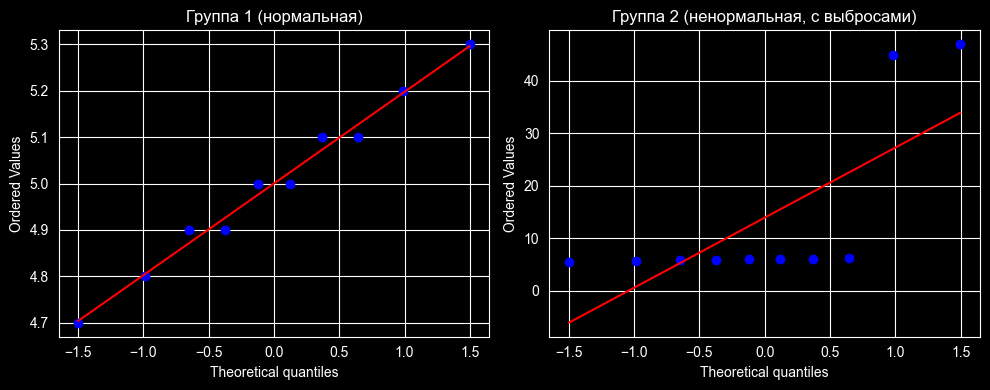

Хотя бы одна группа не нормальна → используем U-тест Манна-Уитни
Mann-Whitney U: U = 0, p-value = 1.7861e-04
Отвергаем H₀: группы статистически значимо различаются.


In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

group1 = np.array([4.8, 5.2, 4.9, 5.1, 5.0, 4.7, 5.3, 5.0, 5.1, 4.9])
group2 = np.array([5.5, 6.0, 5.8, 6.2, 45.0, 5.9, 6.1, 47.0, 5.7, 6.0])

# Тест Шапиро-Уилка
shap1 = stats.shapiro(group1)
shap2 = stats.shapiro(group2)
print(f"Группа 1: W={shap1[0]:.4f}, p={shap1[1]:.4f}")
print(f"Группа 2: W={shap2[0]:.4f}, p={shap2[1]:.4f}")

# Визуализация QQ-plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(group1, dist="norm", plot=axes[0])
axes[0].set_title("Группа 1 (нормальная)")
stats.probplot(group2, dist="norm", plot=axes[1])
axes[1].set_title("Группа 2 (ненормальная, с выбросами)")
plt.tight_layout()
plt.show()

# Условие выбора теста
alpha = 0.05
if shap1[1] > alpha and shap2[1] > alpha:
    print("Обе группы распределены нормально → используем t-тест (Стьюдента)")
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
    print(f"t-тест: t = {t_stat:.4f}, p-value = {p_val:.4e}")
else:
    print("Хотя бы одна группа не нормальна → используем U-тест Манна-Уитни")
    u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    print(f"Mann-Whitney U: U = {u_stat:.0f}, p-value = {p_val:.4e}")

# Интерпретация
if p_val < alpha:
    print("Отвергаем H₀: группы статистически значимо различаются.")
else:
    print("Нет оснований отвергнуть H₀: различия не значимы.")

# 📜 2.3. Проверка распределения на нормальность, QQ‑Plot

## 🧠 Теоретическая справка
Нормальность распределения — важное условие для многих параметрических тестов (t‑тест, ANOVA и др.).  
Для проверки используют:
- **Визуальные методы:** гистограмма, QQ‑plot (квантиль-квантиль график).
- **Статистические тесты:** Шапиро‑Уилка (особенно хорош при n < 50).

## 🎯 Цель практикума
Научиться проверять распределение данных на нормальность с помощью гистограмм, QQ‑plot и теста Шапиро‑Уилка, а также понять, почему QQ‑plot — мощный инструмент для диагностики ненормальности.

## 🧪 Задача
Вы анализируете время безотказной работы (в часах) двух партий жёстких дисков.

### 📊 Данные (генерируем сами)
- **Партия X (нормальное распределение):** 30 значений из `N(μ=500, σ=50)`.
- **Партия Y (экспоненциальное распределение):** 30 значений из `Exponential(scale=400)` — имеет выраженный «тяжёлый правый хвост».

### 🛠 Инструменты
- `numpy.random.normal`, `numpy.random.exponential`
- `scipy.stats.shapiro` — тест Шапиро‑Уилка
- `matplotlib.pyplot` — гистограммы
- `scipy.stats.probplot` — QQ‑plot

### ✅ Задания
1. **Сгенерируйте** две выборки по 30 наблюдений.
2. **Постройте** для каждой партии:
   - гистограмму (с плотностью или частотой);
   - QQ‑plot с прямой линией (теоретическое нормальное распределение).
3. **Проведите** тест Шапиро‑Уилка (`stats.shapiro`) для каждой выборки.
4. **Сравните** результаты:
   - Для партии X точки на QQ‑plot должны лежать близко к прямой, p‑value Шапиро > 0.05.
   - Для партии Y точки будут отклоняться от прямой (особенно на хвостах), p‑value < 0.05.
5. **Объясните** (своими словами или текстом в ячейке), почему QQ‑plot помогает быстрее заметить проблему, чем гистограмма.

## 📈 Пример вывода (ожидание)
- **Партия X:** нормальное распределение → QQ‑plot почти прямая, p‑value ≈ 0.3–0.9.
- **Партия Y:** экспоненциальное распределение → QQ‑plot имеет изогнутый хвост (отклонение вверх справа), p‑value << 0.05.

## 🧠 Вывод для себя
- QQ‑plot чувствителен к отклонениям на хвостах распределения, что критично при проверке условий параметрических тестов.
- Тест Шапиро‑Уилка при больших выборках может отклонить гипотезу о нормальности даже при малых отклонениях — всегда дополняйте его визуальным анализом.

## 📎 Литерал для копирования кода (необязательно)
```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
X = np.random.normal(loc=500, scale=50, size=30)
Y = np.random.exponential(scale=400, size=30)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(X, bins=10, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Гистограмма: партия X')
axes[0,1].hist(Y, bins=10, alpha=0.7, edgecolor='black', color='orange')
axes[0,1].set_title('Гистограмма: партия Y')

stats.probplot(X, dist="norm", plot=axes[1,0])
axes[1,0].set_title('QQ-plot партии X')
stats.probplot(Y, dist="norm", plot=axes[1,1])
axes[1,1].set_title('QQ-plot партии Y')

plt.tight_layout()
plt.show()

print(f"Shapiro-Wilk для X: W={stats.shapiro(X)[0]:.4f}, p={stats.shapiro(X)[1]:.4f}")
print(f"Shapiro-Wilk для Y: W={stats.shapiro(Y)[0]:.4f}, p={stats.shapiro(Y)[1]:.4f}")
```

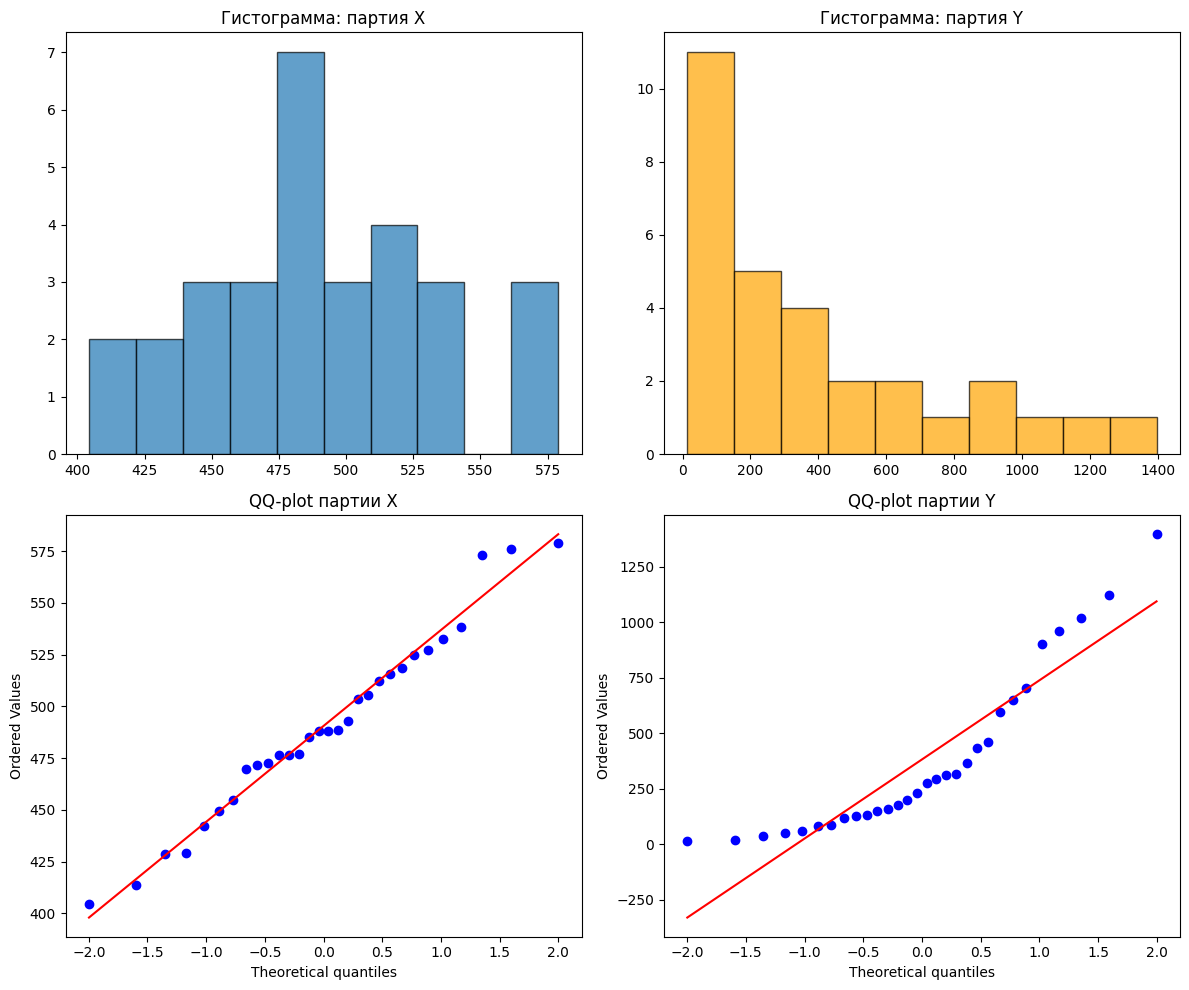

Группа X (Шапиро-тест): 0.98, P-Value: 0.69
Группа Y (Шапиро-тест): 0.84, P-Value: 0.00
Хотя бы одна группа не нормальна → используем U-тест Манна-Уитни
Mann-Whitney U: U = 649, p-value = 3.3386e-03
Отвергаем H₀: группы статистически значимо различаются.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

X = np.random.normal(loc = 500, scale = 50, size = 30)
Y = np.random.exponential(scale = 400, size = 30)


fig, axes = plt.subplots(2,2, figsize=(12,10))


axes[0,0].hist(X, bins=10, alpha=0.7, edgecolor='black')
axes[0,0].set_title('Гистограмма: партия X')
axes[0,1].hist(Y, bins=10, alpha=0.7, edgecolor='black', color='orange')
axes[0,1].set_title('Гистограмма: партия Y')



stats.probplot(X, dist="norm", plot=axes[1,0])
axes[1,0].set_title('QQ-plot партии X')
stats.probplot(Y, dist="norm", plot=axes[1,1])
axes[1,1].set_title('QQ-plot партии Y')

plt.tight_layout()
plt.show()

Shapiro_X, p_valX = stats.shapiro(X)
Shapiro_Y, p_valY = stats.shapiro(Y)

print(f'Группа X (Шапиро-тест): {Shapiro_X:.2f}, P-Value: {p_valX:.2f}')
print(f'Группа Y (Шапиро-тест): {Shapiro_Y:.2f}, P-Value: {p_valY:.2f}')

alfa = 0.05
if p_valX > alfa and p_valY > alfa:
  print('Обе группы имеют нормальное распределение --> используем T-test')
  t_test, p_val = stats.ttest_ind(X, Y, equal_var=False)
  print(f"t-тест: t = {t_test:.4f}, p-value = {p_val:.4e}")
else:
  print('Хотя бы одна группа не нормальна → используем U-тест Манна-Уитни')
  manna_test, p_val = stats.mannwhitneyu(X, Y, alternative='two-sided')
  print(f"Mann-Whitney U: U = {manna_test:.0f}, p-value = {p_val:.4e}")



if p_val < alfa:
  print("Отвергаем H₀: группы статистически значимо различаются.")
else:
    print("Нет оснований отвергнуть H₀: различия не значимы.")






# 📜 2.4. Однофакторный дисперсионный анализ (One‑way ANOVA)

## 🧠 Теоретическая справка
T‑тест позволяет сравнить средние двух групп. Когда групп три и больше, используют **ANOVA** (анализ дисперсии).  
Основная идея: сравнить **межгрупповую дисперсию** (разброс средних между группами) и **внутригрупповую дисперсию** (разброс внутри каждой группы). Если межгрупповая дисперсия значительно больше внутригрупповой, то средние не равны.

## 🎯 Цель практикума
Научиться применять однофакторный ANOVA для сравнения трёх и более групп, визуализировать данные и интерпретировать результаты.

## 🧪 Задача
Производитель кормов для аквариумных рыбок тестирует три рациона: **Standard**, **Pro**, **Premium**. Через 4 недели измерен прирост веса гуппи (в %).

### 📊 Данные
- **Standard:** `[10, 12, 11, 9, 13]`
- **Pro:** `[15, 14, 16, 13, 14]`
- **Premium:** `[20, 18, 19, 21, 22]`

### ✅ Задания
1. Визуализируйте данные с помощью **boxplot** (ящики с усами) для трёх групп.
2. Проведите **однофакторный ANOVA** с помощью `scipy.stats.f_oneway`.
3. Выведите F‑статистику и p‑value.
4. Сделайте вывод на уровне значимости α = 0.05.

### 🛠 Инструменты
- `scipy.stats.f_oneway`
- `matplotlib.pyplot` (boxplot)

## 📈 Ожидаемый результат
- **Понимание:** ANOVA проверяет гипотезу `H₀: μ₁ = μ₂ = μ₃` против `H₁: хотя бы два средних различаются`.
- **Знание:** `f_oneway` возвращает F‑статистику и p‑value. Если p‑value < 0.05, глобальные различия есть, но для выяснения, какие именно группы различаются, нужен **post‑hoc тест** (например, Тьюки).
- Для этих данных p‑value будет очень маленьким (значимые различия).

## 📎 Код (копируй и вставляй)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Данные
standard = np.array([10, 12, 11, 9, 13])
pro = np.array([15, 14, 16, 13, 14])
premium = np.array([20, 18, 19, 21, 22])

# Визуализация
plt.figure(figsize=(8, 6))
plt.boxplot([standard, pro, premium], labels=['Standard', 'Pro', 'Premium'], patch_artist=True)
plt.ylabel('Прирост веса (%)')
plt.title('Сравнение эффективности рационов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ANOVA
f_stat, p_val = stats.f_oneway(standard, pro, premium)

print(f"F-статистика: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

# Вывод
alpha = 0.05
if p_val < alpha:
    print("Отвергаем H₀: различия между рационами статистически значимы.")
else:
    print("Нет оснований отвергнуть H₀: различия не значимы.")

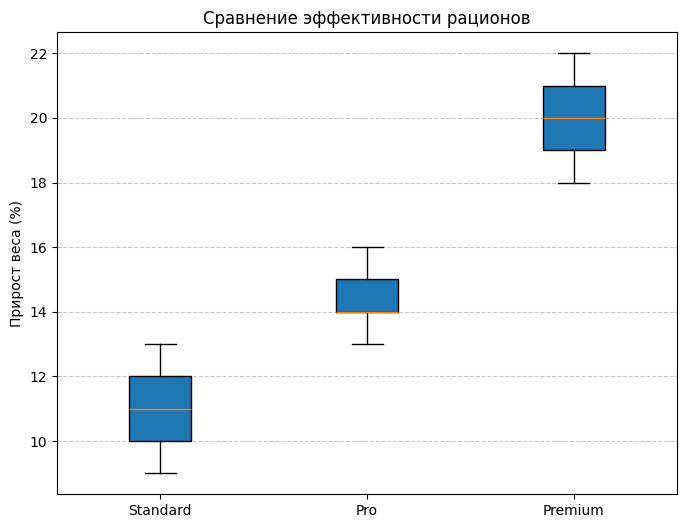

F-статистика: 49.1746
p-value: 1.6538e-06
Отвергаем H₀: различия между рационами статистически значимы.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Данные
standard = np.array([10, 12, 11, 9, 13])
pro = np.array([15, 14, 16, 13, 14])
premium = np.array([20, 18, 19, 21, 22])



plt.figure(figsize=(8,6))
plt.boxplot([standard, pro, premium], tick_labels=['Standard', 'Pro', 'Premium'], patch_artist=True)
plt.ylabel('Прирост веса (%)')
plt.title('Сравнение эффективности рационов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

F_test, p_val =  stats.f_oneway(standard, pro, premium)
print(f"F-статистика: {F_test:.4f}")
print(f"p-value: {p_val:.4e}")

alpha = 0.05
if p_value < alpha:
    print("\nВывод: Отклоняем нулевую гипотезу.")
    print("Между рационами есть статистически значимые различия.")
else:
    print("\nВывод: Не удалось отклонить нулевую гипотезу.")
    print("Статистически значимых различий между рационами не обнаружено.")


# 📜 2.5. Множественные сравнения в ANOVA (Post‑hoc тест Тьюки)

## 🧠 Теоретическая справка
Если ANOVA отверг нулевую гипотезу о равенстве всех средних, возникает вопрос: **какие именно группы различаются между собой?**  
Попарное сравнение с помощью t‑тестов привело бы к накоплению ошибки первого рода (вероятность ложного обнаружения различий растёт с числом сравнений).

**Post‑hoc тесты** (апостериорные) корректируют эту проблему. Один из самых распространённых — **критерий Тьюки (Tukey HSD)**. Он сравнивает все пары групп и выдаёт скорректированные p‑значения.

## 🎯 Цель практикума
Научиться проводить множественные сравнения после значимого ANOVA, интерпретировать результаты и понимать, почему нельзя просто использовать несколько t‑тестов.

## 🧪 Задача (продолжение задачи 2.4)
Производитель кормов для рыбок получил значимый результат ANOVA (различия между тремя рационами есть).  
Требуется выяснить, **какие именно рационы различаются** между собой.

### 📊 Данные (те же)
- **Standard:** `[10, 12, 11, 9, 13]`
- **Pro:** `[15, 14, 16, 13, 14]`
- **Premium:** `[20, 18, 19, 21, 22]`

### ✅ Задания
1. Проведите **ANOVA** (повторите из предыдущей задачи).
2. Выполните **post‑hoc анализ с помощью критерия Тьюки**.
3. Выведите таблицу результатов: сравнение каждой пары групп, разница средних, скорректированный p‑value.
4. Сделайте вывод: какие группы статистически значимо различаются (α = 0.05).

## 🛠 Инструменты
- `scipy.stats.f_oneway` – ANOVA
- `statsmodels.stats.multicomp.pairwise_tukeyhsd` – тест Тьюки (требуется установка `statsmodels`)

> ⚠️ **Если `statsmodels` не установлен:**  
> Выполни в терминале (или в ячейке с `!` в Jupyter):  
> `pip install statsmodels`

## 📈 Ожидаемый результат
- Таблица, где для каждой пары (Standard‑Pro, Standard‑Premium, Pro‑Premium) указаны: разница средних, p‑value (скорректированный), и вывод о значимости.
- С большой вероятностью все три пары будут значимы (p‑value < 0.05), так как данные сильно различаются.

## 📎 Код (копируй и вставляй)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Данные
standard = np.array([10, 12, 11, 9, 13])
pro = np.array([15, 14, 16, 13, 14])
premium = np.array([20, 18, 19, 21, 22])

# Объединяем все значения в один массив
data = np.concatenate([standard, pro, premium])
# Создаём массив меток групп (длины, соответствующие каждой выборке)
labels = ['Standard']*len(standard) + ['Pro']*len(pro) + ['Premium']*len(premium)

# ANOVA (для проверки — будет значим)
f_stat, p_val = stats.f_oneway(standard, pro, premium)
print(f"ANOVA: F = {f_stat:.4f}, p = {p_val:.4e}\n")

# Post-hoc тест Тьюки
tukey = pairwise_tukeyhsd(data, labels, alpha=0.05)
print(tukey)

# Визуализация результатов Тьюки (опционально)
tukey.plot_simultaneous()
plt.title("Tukey HSD — доверительные интервалы разностей средних")
plt.show()

ANOVA: F = 49.1746
p-value: 1.6538e-06
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj   lower    upper  reject
--------------------------------------------------------
Premium      Pro     -5.6 0.0001  -8.0451 -3.1549   True
Premium Standard     -9.0    0.0 -11.4451 -6.5549   True
    Pro Standard     -3.4 0.0078  -5.8451 -0.9549   True
--------------------------------------------------------


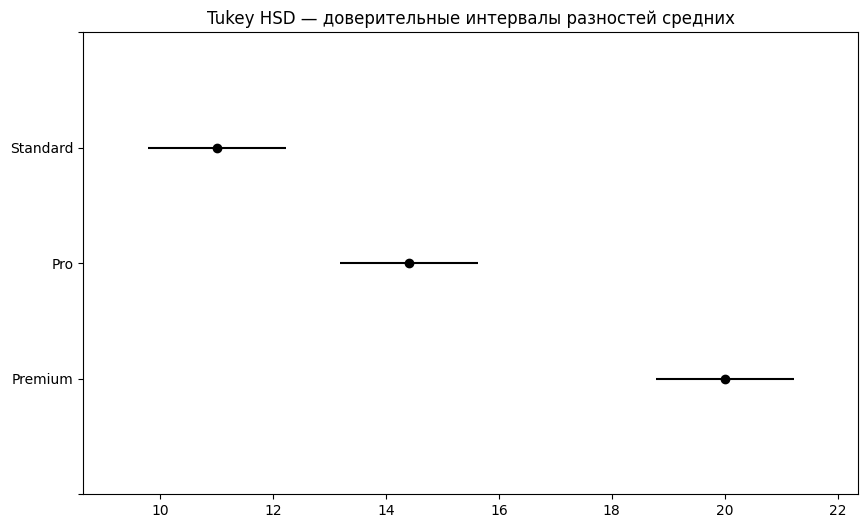

Вывод:
Однофакторный дисперсионный анализ (ANOVA) показал наличие статистически значимых различий между рационами питания (F(2,12)=49.17, p<0.001).
Последующий апостериорный тест Тьюки (Tukey HSD) подтвердил, что все три рациона различаются между собой на уровне значимости α=0.05.
Средний прирост веса гуппи при кормлении рационом Premium статистически значимо выше, чем при использовании Pro и Standard. Поскольку доверительные интервалы разностей средних не пересекают нулевую отметку, мы можем с высокой достоверностью ранжировать рационы по их эффективности: Premium > Pro > Standard


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Данные
standard = np.array([10, 12, 11, 9, 13])
pro = np.array([15, 14, 16, 13, 14])
premium = np.array([20, 18, 19, 21, 22])



data = np.concatenate([standard, pro, premium])
# Создаём массив меток групп (длины, соответствующие каждой выборке)
labels = ['Standard']*len(standard) + ['Pro']*len(pro) + ['Premium']*len(premium)

F_test, p_val = stats.f_oneway(standard, pro, premium)
print(f"ANOVA: F = {F_test:.4f}")
print(f"p-value: {p_val:.4e}")

# Post-hoc тест Тьюки
tukey = pairwise_tukeyhsd(data, labels, alpha=0.05)
print(tukey)

# Визуализация результатов Тьюки (опционально)
tukey.plot_simultaneous()
plt.title("Tukey HSD — доверительные интервалы разностей средних")
plt.show()


print('Вывод:')
print('Однофакторный дисперсионный анализ (ANOVA) показал наличие статистически значимых различий между рационами питания (F(2,12)=49.17, p<0.001).')
print('Последующий апостериорный тест Тьюки (Tukey HSD) подтвердил, что все три рациона различаются между собой на уровне значимости α=0.05.')
print('Средний прирост веса гуппи при кормлении рационом Premium статистически значимо выше, чем при использовании Pro и Standard. Поскольку доверительные интервалы разностей средних не пересекают нулевую отметку, мы можем с высокой достоверностью ранжировать рационы по их эффективности: Premium > Pro > Standard')

